---
# <div style="text-align: center"> Introduction </div>
---

Along these tutorials, we will see how <span style="color:blue">**SCOPE**</span> interacts with the different parts of the code to handle the execution of computational workflows. 

These are the topics covered in each tutorial:
1) The **System** class and its sources: the **Specie**, **Cell** and **Atom** classes  
2) The Computational workflow: **Branch**, **Workflow**, **Job**, and **Computation** classes  
3) The **State** class  
4) The **Data**, **Collection** and **VNM** classes
5) The **Input_data** class, and **scope input files**
6) Running <span style="color:blue">**SCOPE**</span> - Part 1: File Structure
7) Running <span style="color:blue">**SCOPE**</span> - Part 2: Execution 
8) Running <span style="color:blue">**SCOPE**</span> - Part 3: Detailed Actions
9) The Azo add-on: Subclasses, Analysis and Creation of Azo Systems

---
# <div style="text-align: center"> Tutorial 2: The Computational Workflow</div>
---

<span style="color:blue">**SCOPE**</span> aims at automatizing computational workflows, or tasks. To encode the potential complexity of such workflows, it needs a flexible hierarchy of classes, whose purpose might not be evident to a new user.  

As currently implemented, the hierarchy of classes associated with a computational workflow goes like this:  **Branch** -> **Workflow** -> **Job** -> **Computation**.  

From Bottom to Top:
- <span style="color:green">**COMPUTATION**</span>: Starting from the bottom, a **Computation** is associated with an input, an output and a submission file, and contains the information of this single **Computation** that is **submitted** to a computational cluster. Whether it worked or not, SCOPE takes the results into account to decide the course of action.
- <span style="color:green">**JOB**</span>: A **Job** is a single, or a collection of **Computations** with a specific goal. For instance, a **Job** could be the Single Point Energy evaluation of a given structure. It might work with only one computation, or it might need more than one, for instance if convergence issues arise.  
- <span style="color:green">**WORKFLOW**</span>: A collection of **Jobs** for a given molecule or unit cell in a system (i.e a source) form a **Workflow**. For instance, a **Workflow** could be: (1) Optimization with Cheap DFT Functional, (2) Optimization with Expensive DFT Functional, (3) Hessian evaluation (frequencies). Workflows are connected to the **Source** of a **System** 
- <span style="color:green">**BRANCH**</span>: A **Branch** is a collection of related **Workflows**. For instance, the Workflows for the high-spin and low-spin versions of the same molecule can be put together under the same **Branch**.

In this tutorial, we will open an existing **SYSTEM**, stored in a binary file, and navigate the computational workflow inside. Also, we will see how to create a computational workflow manually

In [1]:
import os
import scope

In [2]:
## Path of the data folder. It should be "os.path.abspath('.')+'/Data"
data_folder = os.path.abspath('../')+'/Data/1-Tutorial_1/'

## Loads the System object from a binary file, provided in the tutorial folder
sys = scope.load_binary(f"{data_folder}/Systems/ABITEM/ABITEM.npy")

## This will set the main path of the system to the data folder, so that any new file created by SCOPE will be created in that folder.
sys.set_main_path(data_folder)

[16:55:17] Depickling from a version number (16.3)that is higher than our version (16.2).
This probably won't work.
[16:55:17] Depickling from a version number (16.3)that is higher than our version (16.2).
This probably won't work.
[16:55:17] Depickling from a version number (16.3)that is higher than our version (16.2).
This probably won't work.
[16:55:17] Depickling from a version number (16.3)that is higher than our version (16.2).
This probably won't work.
[16:55:17] Depickling from a version number (16.3)that is higher than our version (16.2).
This probably won't work.
[16:55:17] Depickling from a version number (16.3)that is higher than our version (16.2).
This probably won't work.
[16:55:17] Depickling from a version number (16.3)that is higher than our version (16.2).
This probably won't work.
[16:55:17] Depickling from a version number (16.3)that is higher than our version (16.2).
This probably won't work.
[16:55:17] Depickling from a version number (16.3)that is higher than ou

True

In [3]:
## All objects in SCOPE have a __repr__ method, so printing shows a summary of the object
print(sys)

-------------------------------------
-- >>> SCOPE System_sco Object >>> --
-------------------------------------
 Version               = 1.0
 Type                  = system
 Subtype               = sco_system
 Source Path           = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Sources/ABITEM/
 System File Path      = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Systems/ABITEM/
 System File Name      = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Systems/ABITEM/ABITEM.npy
 Computations Path     = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/

 Num Sources           = 6
     idx: type, name, formula               
     0: cell, ABITEM01, H104-C92-N24-O4-S8-Fe4 
     1: cell, ABITEM, H104-C92-N24-O4-S8-Fe4 
     2: cell, ref_hs_cell, H104-C92-N24-O4-S8-Fe4 
     3: cell, ref_ls_cell, H104-C92-N24-O4-S8-Fe4 
     4: specie, ref_hs_mol, H18-C20-N6-S2

In [4]:
## Shows the branches of a system
print(sys.branches)


[---------------------------------------------------
   >>> BRANCH                                      
---------------------------------------------------
 System                = ABITEM
---------------------------------------------------
 self.status           = active
 self.creation_time    = 10/04/2026 14:35:15
 self.creation_user    = svela
 self.path             = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/solid/
 self.name             = solid
 Num Workflows         = 2

, ---------------------------------------------------
   >>> BRANCH                                      
---------------------------------------------------
 System                = ABITEM
---------------------------------------------------
 self.status           = active
 self.creation_time    = 10/04/2026 14:46:23
 self.creation_user    = svela
 self.path             = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/AB

In [5]:
## Notice that there is an "Isolated" branch, and a "Solid" branch.
## The first contains the computational workflows for the reference molecules
## The second contains the computational workflows for the reference periodic system.

## The "Isolated" Branch

### Branch


In [6]:
## Select a given branch either by selecting it from the list, or searching by name:
found, this_branch = sys.find_branch("Isolated")
print(found)
print(this_branch)

## You'll likely see a WARNING. This is because the branch was created in my computer, and the message is warning that the folders associated with the computations of this branch does not exist in your computer. 
## You can safely ignore this WARNING for the moment. 

True
---------------------------------------------------
   >>> BRANCH                                      
---------------------------------------------------
 System                = ABITEM
---------------------------------------------------
 self.status           = active
 self.creation_time    = 10/04/2026 14:46:23
 self.creation_user    = svela
 self.path             = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/isolated/
 self.name             = isolated
 Num Workflows         = 2




In [7]:
## Workflows are easily accessible. Here there are two workflows, one for the reference high-spin (HS) molecule (ref_hs_mol) and the other for the low-spin (LS) one (ref_ls_mol)
this_branch.workflows

[---------------------------------------------------
    >>> >>> WORKFLOW                                
 ---------------------------------------------------
  Source Name                 = ref_hs_mol
  Source Type                 = specie
  Source sub-Type             = molecule
  Source Charge               = 0
  Source Spin                 = 4
 ---------------------------------------------------
  Workflow Name               = ref_hs_mol
  Num Jobs                    = 3
 	Last Job Name        = freq
 	Last Job Hierarchy   = 3
 ,
 ---------------------------------------------------
    >>> >>> WORKFLOW                                
 ---------------------------------------------------
  Source Name                 = ref_ls_mol
  Source Type                 = specie
  Source sub-Type             = molecule
  Source Charge               = 0
  Source Spin                 = 0
 ---------------------------------------------------
  Workflow Name               = ref_ls_mol
  Num Jobs    

### Workflow 

In [8]:
## Again, you can select a given workflow either by selecting it from the list, or searching by name of the source:
found, this_workflow = this_branch.find_workflow("ref_hs_mol")
print(found)
print(this_workflow)

True
---------------------------------------------------
   >>> >>> WORKFLOW                                
---------------------------------------------------
 Source Name                 = ref_hs_mol
 Source Type                 = specie
 Source sub-Type             = molecule
 Source Charge               = 0
 Source Spin                 = 4
---------------------------------------------------
 Workflow Name               = ref_hs_mol
 Num Jobs                    = 3
	Last Job Name        = freq
	Last Job Hierarchy   = 3




In [9]:
## This workflow has 3 Jobs, the latest being a b3lyp frequency computation
this_workflow.jobs

[---------------------------------------------------
    >>> >>> >>> JOB                                 
 ---------------------------------------------------
  Source Type           = specie
  Source Name           = ref_hs_mol
  Branch Name           = isolated
  Workflow Name         = ref_hs_mol
 ---------------------------------------------------
  Job path              = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/isolated/
  Job name              = opt
  Job type              = opt
  Job hierarchy         = 1
  Job requisites        = []
  Job constrains        = ['self']
  Job setup             = regular
  Num Computations      = 1
 ----------------------------------------------------
  self.isregistered (Temp) = True
  self.isgood       (Temp) = True
  self.isfinished   (Temp) = True
 ,
 ---------------------------------------------------
    >>> >>> >>> JOB                                 
 -----------------------------------

### Job

In [10]:
## Again, you can select a given JOB either by selecting it from the list, or searching by name of the keyword:
found, this_job = this_workflow.find_job('opt2') ## opt2 is the name given to the b3lyp* optimization
print(found)
print(this_job)

## Alternatively, you can also search by hierarchy number:
found, that_job = this_workflow.find_job(hierarchy=2) ## hierarchy goes from 1 onwards.
print(found)
print(that_job)


True
---------------------------------------------------
   >>> >>> >>> JOB                                 
---------------------------------------------------
 Source Type           = specie
 Source Name           = ref_hs_mol
 Branch Name           = isolated
 Workflow Name         = ref_hs_mol
---------------------------------------------------
 Job path              = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/isolated/
 Job name              = opt2
 Job type              = opt
 Job hierarchy         = 2
 Job requisites        = ['opt']
 Job constrains        = ['self']
 Job setup             = regular
 Num Computations      = 1
----------------------------------------------------
 self.isregistered (Temp) = True
 self.isgood       (Temp) = True
 self.isfinished   (Temp) = True


True
---------------------------------------------------
   >>> >>> >>> JOB                                 
-------------------------------------------

In [11]:
## Both ways you retrieve the same job.
this_job == that_job

True

In [12]:
## Notice that jobs have requisites and constrains. This means that, when submitting this job, it won't run unless those in requisites have finished and those in constrains have not finished.
print(this_job.requisites)
print(this_job.constrains)

['opt']
['self']


In [13]:
## Jobs store the information provided by the user here:
print(this_job.job_data)
## Some entries inside job_data create an attribute in the object, so you can access those data as either:
print(this_job.istate, '-->', this_job.job_data.istate) 

Formatted input interpretation: ( self -> Instance of class Input() )
---------------------------------------------------
self.Key                 | Data Type           | Value     
---------------------------------------------------
self.branch              | <class 'str'>       | isolated  
self.workflow            | <class 'list'>      | ['ref_hs_mol', 'ref_ls_mol']
self.job                 | <class 'str'>       | opt2      
self.istate              | <class 'str'>       | pbe_opt   
self.fstate              | <class 'str'>       | b3lyp_opt 
self.hierarchy           | <class 'int'>       | 2         
self.requisites          | <class 'list'>      | ['opt']   
self.constrains          | <class 'list'>      | ['self']  
self.must_be_good        | <class 'bool'>      | True      
self.job_setup           | <class 'str'>       | regular   
self.job_type            | <class 'str'>       | opt       

pbe_opt --> pbe_opt


In [14]:
## Some of this information will be discussed below when talking about the computations. An important bit are .istate and .fstate
print(this_job.istate)
print(this_job.fstate)
## States are a way to manage the results of computations. They are discussed in Tutorial 2
## For the moment, suffices to say that computations take the information from an initial state, and output the information to a final state, that can be the same.

## In this case, the job reads the data from the PBE_OPT state (e.g. initial geometry) and the result from a B3LYP optimization is stored in a final state called B3LYP_OPT.
## Because B3LYP_OPT state does not exist when submitting the computation, the new state will be automatically created

pbe_opt
b3lyp_opt


### Computation

In [15]:
## You can access the computations by selecting it from the list, or searching by step and run_number
found, this_comp = this_job.find_computation(step=1, run_number=1) ## both step and run_number go from 1 onwards.
print(found)
print(this_comp)

True
---------------------------------------------------
   >>> >>> >>> >>> COMPUTATION                     
---------------------------------------------------
 Source Type           = specie
 Source sub-Type       = molecule
 Branch Name           = isolated
 Workflow Name         = ref_hs_mol
 Job Name              = opt2
 Job Type              = opt
---------------------------------------------------
 Initial State         = pbe_opt
 Final State           = b3lyp_opt
 Comp software         = g16
 Comp index            = 1
 Comp step             = 1
 Comp run_number       = 1
 Comp inp_path         = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/isolated/ABITEM_ref_hs_mol_opt2_r1.com
 Comp out_path         = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/isolated/ABITEM_ref_hs_mol_opt2_r1.log
 Comp isregistered     = True
 Comp isgood           = True
 Comp isfinished       = True
 Comp 

In [16]:
## If everything goes well, most jobs will be completed after a single computation, with step=1 and run_number=1. 
print(this_comp.step, this_comp.run_number, this_comp.isgood)
## Larger values for "run_number" are typical if a computation fails to complete the task.
## In such cases multiple computations with increasing run_number values will be created and run.


1 1 True


In [17]:
## There is only one type of job setup for which "step" can be different than 1. Currently, the setup type of this job is:
print(this_job.job_setup)

## When .setup is "rep_opt", it will run several 'external' steps of geometry optimization until the energy converges. This is relevant in variable-cell geometry optimizations of unit-cells.
## With Quantum Espresso, variable-cell geo-opts computations can finish successfuly, supposedly giving you the minimum energy structure. 
## However, if you re-submit a new computation to continue the previous one, the energy might still go down significanlty. This is related to how Plane-waves react to the change of cell size.


regular


In [18]:
## The paths of the input and output files are stored. The name of these files (not the extension) is decided here
this_comp.filename

sys_name: ABITEM, Format: ABITEM
sou_name: ref_hs_mol, Format: ref_hs_mol
job_name: opt2, Format: opt2
run_number: 1, Format: r1

In [19]:
## The Quantum Chemistry parameters of this computation are stored in .qc_data: 
this_comp.qc_data

Formatted input interpretation: ( self -> Instance of class Input() )
---------------------------------------------------
self.Key                 | Data Type           | Value     
---------------------------------------------------
self.software            | <class 'str'>       | g16       
self.comp_type           | <class 'str'>       | opt       
self.functional          | <class 'str'>       | b3lyp**   
self.basis               | <class 'str'>       | def2svp   
self.is_grimme           | <class 'bool'>      | True      
self.loose_opt           | <class 'bool'>      | False     
self.tight_opt           | <class 'bool'>      | False     
self.ultrafine_grid      | <class 'bool'>      | False     
self.grimme_type         | <class 'str'>       | d3bj      
self.fctype              | <class 'str'>       | recalcfc  
self.recalc_steps        | <class 'int'>       | 30        
self.fstate              | <class 'str'>       | b3lyp_opt 
self.istate              | <class 'str'>      

In [20]:
## Some of this parameters are defined by the used in the job_file that specifies which computation must be done, and some other information is completed by the code.
## Basically, it adds some defaults.

In [21]:
## Once finished, the computation is registered. This means that the output is read, and the relevant information parsed.
## This is done through the "OUTPUT" class. There is one output class for each of the implemented softwares (for the moment, Gaussian and Quantum Espresso)
## When parsing outputs, an output class will read the lines of the output file, and will be our platform to parse the output file.
## Once finished, the lines of the output file are removed from memory. So we need to re-read the output file to parse it again. 

## Now we do it by just creating the OUTPUT object:
output = this_comp.create_output()
print(output)

---------------------------------------------------
          SCOPE Gaussian16 OUTPUT CLASS            
---------------------------------------------------
 Num of Lines     = 67424
 Computation Type = opt
 Requisites       = ['scf', 'opt']
---------------------------------------------------



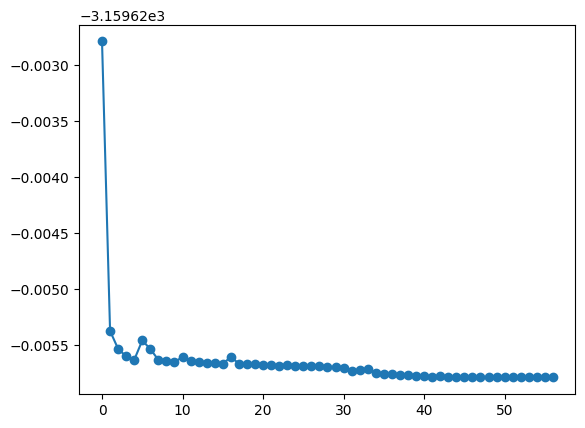

In [22]:
import matplotlib.pyplot as plt

## And now we can parse some relevant data:
energies = output.get_all_energies()
plt.plot(range(len(energies)), energies)
plt.scatter(range(len(energies)), energies)

In [23]:
from scope.read_write import print_xyz
labels, coordinates = output.get_geometry_last_complete_block()
print_xyz(labels, coordinates)

Fe  3.774774  3.779086  13.494815
S  1.627444  1.260647  16.645926
S  7.775067  6.070671  13.495128
N  4.388366  3.012781  11.573830
N  1.554286  4.139279  12.893164
N  3.225163  5.467599  14.748913
N  3.827655  5.637491  12.021693
N  3.234103  2.168291  14.532057
N  5.756036  4.156787  13.919598
C  4.403060  1.697532  11.314345
H  3.957564  1.056936  12.084132
C  4.962006  1.177906  10.147158
H  4.961604  0.098755  9.972590
C  5.513741  2.066869  9.219480
H  5.958902  1.697928  8.290368
C  5.487222  3.436157  9.493861
H  5.907017  4.161215  8.790346
C  4.922063  3.878771  10.694095
C  4.921934  5.340535  11.088554
H  5.883024  5.575005  11.579678
H  4.870551  5.973670  10.179266
C  0.533820  3.647869  13.609127
H  0.732976  2.747319  14.197467
C  0.147563  5.942191  12.164908
H  0.039650  6.860404  11.579998
C  1.366696  5.259855  12.173612
C  2.536976  5.694780  11.324614
H  2.590071  4.995985  10.471859
H  2.354671  6.703981  10.903917
C  2.671356  5.317313  15.960915
H  2.556322  4

## The "Solid" Branch

This is to show that the same behavior is expected for branches associated with a different type of computation (in this case, QE)

In [29]:
## Here, we go down the hierarchy, until reaching the first relax computation for the ref_hs_cell workflow
found, solid_branch   = sys.find_branch("Solid")
found, solid_workflow = solid_branch.find_workflow("ref_hs_cell")
found, solid_job      = solid_workflow.find_job("relax")
found, solid_comp     = solid_job.find_computation(run_number=1)
found

True

In [28]:
solid_comp

---------------------------------------------------
   >>> >>> >>> >>> COMPUTATION                     
---------------------------------------------------
 Source Type           = cell
 Source sub-Type       = sco_cell
 Branch Name           = solid
 Workflow Name         = ref_hs_cell
 Job Name              = relax
 Job Type              = relax
---------------------------------------------------
 Initial State         = initial
 Final State           = relax
 Comp software         = qe
 Comp index            = 1
 Comp step             = 1
 Comp run_number       = 1
 Comp inp_path         = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/solid/ABITEM_ref_hs_cell_relax_r1.input
 Comp out_path         = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/solid/ABITEM_ref_hs_cell_relax_r1.out
 Comp isregistered     = False
 Has OUTPUT            = NO


In [30]:
solid_comp.qc_data

Formatted input interpretation: ( self -> Instance of class Input() )
---------------------------------------------------
self.Key                 | Data Type           | Value     
---------------------------------------------------
self.software            | <class 'str'>       | qe        
self.comp_type           | <class 'str'>       | relax     
self.version             | <class 'float'>     | 7.0       
self.functional          | <class 'str'>       | pbe       
self.is_hubbard          | <class 'bool'>      | True      
self.uterm               | <class 'float'>     | 2.35      
self.is_grimme           | <class 'bool'>      | True      
self.grimme_type         | <class 'str'>       | d3bj      
self.mix_beta            | <class 'float'>     | 0.7       
self.elec_conv           | <class 'float'>     | 1e-05     
self.pseudo              | <class 'str'>       | vanderbilt
self.pp_library          | <class 'str'>       | vanderbilt
self.print_forces        | <class 'bool'>     

---
## How to Create a Computational Workflow Manually (Branch, Workflow, Job, Computation). <span style="color:red">Not recommended</span> 
---

In this tutorial, we have navigated the computational workflow of an existing System (sys).

- sys had one branch ("*isolated*")
- isolated had two workflows ("*ref_hs_mol*" and "*ref_ls_mol*"), referring to two of the system's sources
- each workflow had three jobs ("*pbe scf*", "*pbe opt*", "*b3lyp opt*")
- each job had computations

This setup above was created automatically by SCOPE when running the workflow, based on the user's choice,  
which are detailed in formatted input files that are explained in Tutorial 5.  

You are **NOT** expected to handle the computational workflow **manually**. Indeed, it is <span style="color:red">**Not recommended**</span>. 
However, it is possible:

### Creating a Branch

In [25]:
## This is our system, with the "isolated" and "solid" Branches (at least for now)
sys

-------------------------------------
-- >>> SCOPE System_sco Object >>> --
-------------------------------------
 Version               = 1.0
 Type                  = system
 Subtype               = sco_system
 Source Path           = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Sources/ABITEM/
 System File Path      = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Systems/ABITEM/
 System File Name      = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Systems/ABITEM/ABITEM.npy
 Computations Path     = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/

 Num Sources           = 6
     idx: type, name, formula               
     0: cell, ABITEM01, H104-C92-N24-O4-S8-Fe4 
     1: cell, ABITEM, H104-C92-N24-O4-S8-Fe4 
     2: cell, ref_hs_cell, H104-C92-N24-O4-S8-Fe4 
     3: cell, ref_ls_cell, H104-C92-N24-O4-S8-Fe4 
     4: specie, ref_hs_mol, H18-C20-N6-S2

In [24]:
# Branches can be easily created. By default, a folder is also created
# This folder is where all computations associated with this branch would be stored, but here we don't need it
new_branch = sys.add_branch("Tutorial", create_folder=False)

# If you run this cell twice, you'll get a message saying that the branch already exists. 
# The same branch (with the same name) cannot be created twice in the same system. The same applies to workflows and jobs inside a branch/workflow respectively.

## Here's the newly created branch
print(new_branch)

## When creating SOURCES, BRANCHES and WORKFLOWS, all names are de-capitalized and spaces are replaced by underscores.
## Notice that the name of the branch is now "tutorial" instead of "Tutorial"

---------------------------------------------------
   >>> BRANCH                                      
---------------------------------------------------
 System                = ABITEM
---------------------------------------------------
 self.status           = active
 self.creation_time    = 13/03/2026 16:53:46
 self.creation_user    = sergivela
 self.path             = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/tutorial/
 self.name             = tutorial
 Num Workflows         = 0




In [25]:
# Notice that a new Branch appears in the system
print(sys)

-------------------------------------
-- >>> SCOPE System_sco Object >>> --
-------------------------------------
 Version               = 1.0
 Type                  = system
 Subtype               = sco_system
 Source Path           = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Sources/ABITEM/
 System File Path      = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Systems/ABITEM/
 System File Name      = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Systems/ABITEM/ABITEM.npy
 Computations Path     = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/

 Num Sources           = 6
     idx: type, name, formula               
     0: cell, ABITEM01, H104-C92-N24-O4-S8-Fe4 
     1: cell, ABITEM, H104-C92-N24-O4-S8-Fe4 
     2: cell, ref_hs_cell, H104-C92-N24-O4-S8-Fe4 
     3: cell, ref_ls_cell, H104-C92-N24-O4-S8-Fe4 
     4: specie, ref_hs_mol, H18-C20-N6-S2

### Creating a Workflow

In [26]:
# Similarly, workflows can be created inside a branch. Only the source name is needed
new_workflow1 = new_branch.add_workflow("ref_hs_cell")
new_workflow2 = new_branch.add_workflow("ref_ls_cell")

print(new_workflow1)

---------------------------------------------------
   >>> >>> WORKFLOW                                
---------------------------------------------------
 Source Name                 = ref_hs_cell
 Source Type                 = cell
 Source sub-Type             = sco_cell
 Source Charge               = 0
 Source Spin                 = 16
 Source Phase                = HS
---------------------------------------------------
 Workflow Name               = ref_hs_cell
 Num Jobs                    = 0




### Creating a Job

In [27]:
# To create a Job, we need to provide the job_data file. For simplicity, we can use the same one as above in the existing job: this_job.job_data
new_job = new_workflow1.add_job(this_job.job_data)

In [28]:
# The new job should now appear in the workflow. Here the workflow:
new_workflow1

---------------------------------------------------
   >>> >>> WORKFLOW                                
---------------------------------------------------
 Source Name                 = ref_hs_cell
 Source Type                 = cell
 Source sub-Type             = sco_cell
 Source Charge               = 0
 Source Spin                 = 16
 Source Phase                = HS
---------------------------------------------------
 Workflow Name               = ref_hs_cell
 Num Jobs                    = 1
	Last Job Name        = opt2
	Last Job Hierarchy   = 2


In [29]:
# and here the job:
new_job

---------------------------------------------------
   >>> >>> >>> JOB                                 
---------------------------------------------------
 Source Type           = cell
 Source Name           = ref_hs_cell
 Branch Name           = tutorial
 Workflow Name         = ref_hs_cell
---------------------------------------------------
 Job path              = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/tutorial/
 Job name              = opt2
 Job type              = opt
 Job hierarchy         = 2
 Job requisites        = ['opt']
 Job constrains        = ['self']
 Job setup             = regular
 Num Computations      = 0
----------------------------------------------------
 self.isregistered (Temp) = False
 self.isgood       (Temp) = False
 self.isfinished   (Temp) = False


### Creating a Computation

In [30]:
# To create a Computation, we need to provide the qc_data. Again, for simplicity we can use the same one as above in the existing computation: this_comp.qc_data
new_comp = new_job.add_computation(this_comp.qc_data)

# Apart from that, computations need some more preparation:
# - This is to set the name of the computation files:
new_comp.set_name()
new_comp.set_paths()
# - And this is to connect the computation with the initial and final states:
new_comp.qc_data._add_attr("istate",new_job.istate)
new_comp.qc_data._add_attr("fstate",new_job.fstate)

# Alternatively, you can just use:
#new_job.set_computations_from_setup(this_comp.qc_data)

## This instruction will create 'all' computations expected from the job setup, and prepare them properly.
## I say 'all' instead of 'one' because some job setups require multiple computations (e.g. findiff) 

In [31]:
# Eventually, the computation should appear in the job (see Num Computations)
new_job


---------------------------------------------------
   >>> >>> >>> JOB                                 
---------------------------------------------------
 Source Type           = cell
 Source Name           = ref_hs_cell
 Branch Name           = tutorial
 Workflow Name         = ref_hs_cell
---------------------------------------------------
 Job path              = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/tutorial/
 Job name              = opt2
 Job type              = opt
 Job hierarchy         = 2
 Job requisites        = ['opt']
 Job constrains        = ['self']
 Job setup             = regular
 Num Computations      = 1
----------------------------------------------------
 self.isregistered (Temp) = False
 self.isgood       (Temp) = False
 self.isfinished   (Temp) = False


## Resetting a Workflow

The objects associated with the computational workflow can be manually removed: 

In [32]:
new_job.remove_computation(comp_keyword='', remove_files=False)
new_workflow1.remove_job(name='opt2')
new_branch.remove_workflow('ref_hs_cell')
sys.remove_branch("tutorial") ## or, alternatively: sys.remove_all_branches()

In [ ]:
## And now, the "tutorial" branch is gone
sys

-------------------------------------
-- >>> SCOPE System_sco Object >>> --
-------------------------------------
 Version               = 1.0
 Type                  = system
 Subtype               = sco_system
 Source Path           = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Sources/ABITEM/
 System File Path      = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Systems/ABITEM/
 System File Name      = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Systems/ABITEM/ABITEM.npy
 Computations Path     = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/

 Num Sources           = 6
     idx: type, name, formula               
     0: cell, ABITEM01, H104-C92-N24-O4-S8-Fe4 
     1: cell, ABITEM, H104-C92-N24-O4-S8-Fe4 
     2: cell, ref_hs_cell, H104-C92-N24-O4-S8-Fe4 
     3: cell, ref_ls_cell, H104-C92-N24-O4-S8-Fe4 
     4: specie, ref_hs_mol, H18-C20-N6-S2